<a href="https://colab.research.google.com/github/EmanFatima206/research-paper-topic-classifier/blob/main/Research_Paper_Topic_Classifier.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load dataset directly from GitHub
data_url = "https://raw.githubusercontent.com/EmanFatima206/research-paper-topic-classifier/main/arxiv_data.csv"

data = pd.read_csv(data_url)

#data = pd.read_csv('arXiv-DataFrame.csv')

# Show first 5 rows
data.head()

,Title,Summary,Topic
0,Dynamic Backtracking,Because of their occasional need to return to ...,cs.AI
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,cs.AI
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,cs.AI
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,cs.AI
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,cs.AI


In [ ]:
# Check number of rows and columns
print("Dataset Shape:", data.shape)

# Check column names
print("\nColumn Names:")
print(data.columns.tolist())

Dataset Shape: (53474, 10)

Column Names:
['Unnamed: 0', 'id', 'Title', 'Summary', 'Author', 'Link', 'Publish Date', 'Update Date', 'Primary Category', 'Category']


In [ ]:
# Check data types and non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53474 entries, 0 to 53473
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        53474 non-null  int64 
 1   id                53474 non-null  object
 2   Title             53474 non-null  object
 3   Summary           53474 non-null  object
 4   Author            53474 non-null  object
 5   Link              53474 non-null  object
 6   Publish Date      53474 non-null  object
 7   Update Date       53474 non-null  object
 8   Primary Category  53474 non-null  object
 9   Category          53474 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.1+ MB


In [ ]:
# Check missing values in each column
print(data.isnull().sum())

Unnamed: 0          0
id                  0
Title               0
Summary             0
Author              0
Link                0
Publish Date        0
Update Date         0
Primary Category    0
Category            0
dtype: int64


In [ ]:
# Number of unique categories
print("Number of unique categories:",
      data['Category'].nunique())

# Number of papers in each category
print("\nPapers per category:")
print(data['Category'].value_counts())

Number of unique categories: 8670

Papers per category:
Category
['cs.IT', 'math.IT']                                                                      590
['math-ph', 'math.MP']                                                                    540
['econ.GN', 'q-fin.EC']                                                                   354
['cond-mat.soft']                                                                         350
['cond-mat.dis-nn']                                                                       350
                                                                                         ... 
['stat.OT', '62N05 94A17']                                                                  1
['stat.OT', '62C10, 62C12', 'F.1.2; G.3; G.4']                                              1
['stat.OT', '62N01, 62N02']                                                                 1
['cs.AI', 'F.4.1;I.2.4;I.2.3']                                                           

In [ ]:
# Show some unique category values
print(data['Category'].unique()[:20])

["['cs.AI']" "['cs.AI', 'I.2.8']" "['cs.AI', 'I.1.2; I.2.2']"
 "['cs.AI', 'I.2.0']" "['cs.AI', 'I.2.8; I.2.1; J.6; I.2.4; F.2.2']"
 "['cs.AI', 'I.2']" "['cs.AI', 'D.1.6']" "['cs.AI', 'I.2.3; I.2.7']"
 "['cs.AI', 'I.2.3; I.2.4']" "['cs.AI', 'A.m']" "['cs.AI', 'I.2.3']"
 "['cs.AI', 'F.4.1']" "['cs.AI', 'I.2.4;F.4.1']"
 "['cs.AI', 'F.4.1;I.2.3;I.2.4']"
 "['cs.AI', 'Artificial intelligence and nonmonotonic reasoning and belief\\n  revision']"
 "['cs.AI', 'F.4.1;I.2.4;I.2.3']" "['cs.AI', 'I.2.3;I.2.8']"
 "['cs.AI', 'I.2.4; F.4.1']" "['cs.AI', 'F.4.1; I.2.3']"
 "['cs.AI', 'I.2.4']"]


In [ ]:
# Check duplicate rows
print("Duplicate rows:", data.duplicated().sum())

print("Duplicate titles:", data['Title'].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 1159


In [ ]:
# Check number of unique primary categories
print("Number of Primary Categories:",
      data['Primary Category'].nunique())

# Show papers per primary category
print("\nPapers per Primary Category:")
print(data['Primary Category'].value_counts().head(30))

Number of Primary Categories: 154

Papers per Primary Category:
Primary Category
math.ST               702
math-ph               701
cs.IT                 700
cond-mat.stat-mech    383
cond-mat.soft         373
econ.GN               371
physics.bio-ph        369
cs.CY                 368
q-fin.GN              367
q-bio.BM              364
cs.DC                 363
q-bio.QM              362
q-bio.MN              362
cs.SE                 361
cs.AI                 360
physics.soc-ph        358
cs.NI                 358
cs.CR                 357
cs.MA                 357
math.HO               356
cs.PF                 356
cs.SY                 356
cond-mat.dis-nn       355
cs.DB                 355
cs.DL                 355
quant-ph              355
cs.LG                 355
cs.HC                 354
cs.GT                 354
q-bio.NC              354
Name: count, dtype: int64


In [ ]:
selected_categories = [
    'cs.AI',   # Artificial Intelligence
    'cs.LG',   # Machine Learning
    'cs.CV',   # Computer Vision
    'cs.CL',   # Natural Language Processing
    'cs.CR',   # Cryptography and Security
    'cs.IR',   # Information Retrieval
    'cs.RO'    # Robotics
]

In [ ]:
filtered_data = data[
    data['Primary Category'].isin(selected_categories)
].copy()

print("Filtered Dataset Shape:", filtered_data.shape)

print("\nPapers per Category:")
print(filtered_data['Primary Category'].value_counts())

Filtered Dataset Shape: (2328, 10)

Papers per Category:
Primary Category
cs.AI    360
cs.CR    357
cs.LG    355
cs.CL    352
cs.CV    352
cs.IR    352
cs.RO    200
Name: count, dtype: int64


In [ ]:
filtered_data = filtered_data[
    ['Title', 'Summary', 'Primary Category']
].copy()

filtered_data.head()

,Title,Summary,Primary Category
0,Dynamic Backtracking,Because of their occasional need to return to ...,cs.AI
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,cs.AI
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,cs.AI
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,cs.AI
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,cs.AI


In [ ]:
filtered_data.rename(
    columns={'Primary Category': 'Topic'},
    inplace=True
)

filtered_data.head()

,Title,Summary,Topic
0,Dynamic Backtracking,Because of their occasional need to return to ...,cs.AI
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,cs.AI
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,cs.AI
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,cs.AI
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,cs.AI


In [ ]:
print(filtered_data.isnull().sum())

Title      0
Summary    0
Topic      0
dtype: int64


In [ ]:
print("Duplicate rows before removal:",
      filtered_data.duplicated().sum())

filtered_data = filtered_data.drop_duplicates()

print("Dataset Shape after removing duplicates:",
      filtered_data.shape)



Duplicate rows before removal: 0
Dataset Shape after removing duplicates: (2328, 3)


In [ ]:
filtered_data = filtered_data.drop_duplicates(
    subset=['Title', 'Summary']
)

print("Final Shape:",
      filtered_data.shape)

Final Shape: (2328, 3)


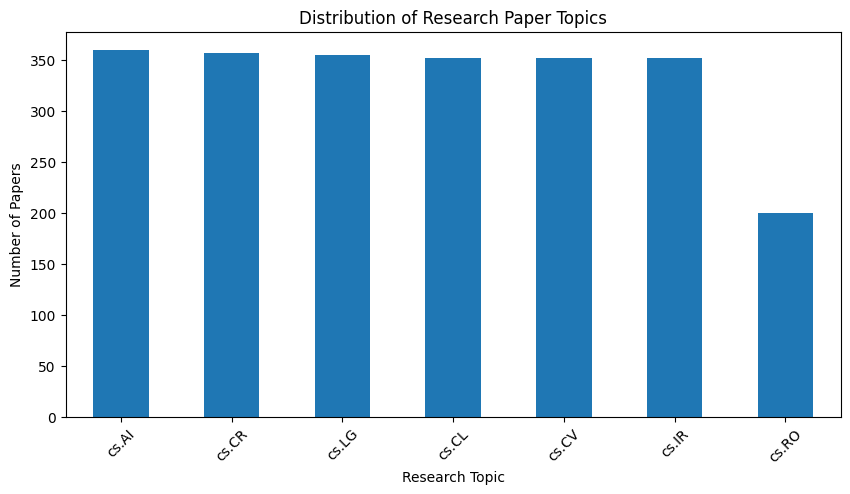

In [ ]:
category_counts = filtered_data['Topic'].value_counts()

plt.figure(figsize=(10, 5))

category_counts.plot(kind='bar')

plt.title('Distribution of Research Paper Topics')
plt.xlabel('Research Topic')
plt.ylabel('Number of Papers')

plt.xticks(rotation=45)



plt.savefig(
    'category_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
filtered_data['Text'] = (
    filtered_data['Title'].astype(str)
    + ' '
    + filtered_data['Summary'].astype(str)
)

filtered_data[['Title', 'Summary', 'Text', 'Topic']].head()

,Title,Summary,Text,Topic
0,Dynamic Backtracking,Because of their occasional need to return to ...,Dynamic Backtracking Because of their occasion...,cs.AI
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,A Market-Oriented Programming Environment and ...,cs.AI
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,An Empirical Analysis of Search in GSAT We des...,cs.AI
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,The Difficulties of Learning Logic Programs wi...,cs.AI
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,Software Agents: Completing Patterns and Const...,cs.AI


In [ ]:
import re

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
filtered_data['Clean_Text'] = filtered_data['Text'].apply(clean_text)

filtered_data[['Text', 'Clean_Text']].head()

,Text,Clean_Text
0,Dynamic Backtracking Because of their occasion...,dynamic backtracking because of their occasion...
1,A Market-Oriented Programming Environment and ...,a market oriented programming environment and ...
2,An Empirical Analysis of Search in GSAT We des...,an empirical analysis of search in gsat we des...
3,The Difficulties of Learning Logic Programs wi...,the difficulties of learning logic programs wi...
4,Software Agents: Completing Patterns and Const...,software agents completing patterns and constr...


In [ ]:
print("ORIGINAL TEXT:\n")
print(filtered_data['Text'].iloc[0])

print("\n---------------------------------\n")

print("CLEANED TEXT:\n")
print(filtered_data['Clean_Text'].iloc[0])

ORIGINAL TEXT:

Dynamic Backtracking Because of their occasional need to return to shallow points in a search tree, existing backtracking methods can sometimes erase meaningful progress toward solving a search problem. In this paper, we present a method by which backtrack points can be moved deeper in the search space, thereby avoiding this difficulty. The technique developed is a variant of dependency-directed backtracking that uses only polynomial space while still providing useful control information and retaining the completeness guarantees provided by earlier approaches.

---------------------------------

CLEANED TEXT:

dynamic backtracking because of their occasional need to return to shallow points in a search tree existing backtracking methods can sometimes erase meaningful progress toward solving a search problem in this paper we present a method by which backtrack points can be moved deeper in the search space thereby avoiding this difficulty the technique developed is a var

In [ ]:
X = filtered_data['Clean_Text']
y = filtered_data['Topic']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2328,)
y Shape: (2328,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1862
Testing samples: 466


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=40000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:",
      X_train_tfidf.shape)

print("Testing TF-IDF Shape:",
      X_test_tfidf.shape)

Training TF-IDF Shape: (1862, 18148)
Testing TF-IDF Shape: (466, 18148)


## First Model: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

## Logistic Regression evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average='weighted'
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

print("Logistic Regression Weighted F1:",
      logistic_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

Logistic Regression Accuracy: 0.8648068669527897
Logistic Regression Weighted F1: 0.86655936150348

Classification Report:

              precision    recall  f1-score   support

       cs.AI       0.71      0.86      0.78        72
       cs.CL       0.94      0.84      0.89        70
       cs.CR       0.96      0.96      0.96        72
       cs.CV       0.92      0.87      0.90        70
       cs.IR       0.86      0.90      0.88        71
       cs.LG       0.77      0.75      0.76        71
       cs.RO       1.00      0.88      0.93        40

    accuracy                           0.86       466
   macro avg       0.88      0.87      0.87       466
weighted avg       0.87      0.86      0.87       466



## Second Model: Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

## Evaluation

In [ ]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average='weighted'
)

print("SVM Accuracy:", svm_accuracy)
print("SVM Weighted F1:", svm_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        svm_predictions
    )
)

SVM Accuracy: 0.8776824034334764
SVM Weighted F1: 0.877356494912401

Classification Report:

              precision    recall  f1-score   support

       cs.AI       0.78      0.86      0.82        72
       cs.CL       0.90      0.89      0.89        70
       cs.CR       0.96      0.97      0.97        72
       cs.CV       0.91      0.86      0.88        70
       cs.IR       0.87      0.92      0.89        71
       cs.LG       0.80      0.73      0.76        71
       cs.RO       0.97      0.95      0.96        40

    accuracy                           0.88       466
   macro avg       0.88      0.88      0.88       466
weighted avg       0.88      0.88      0.88       466



## Third Model: Multinomial Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

## evaluation

In [ ]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average='weighted'
)

print("Naive Bayes Accuracy:",
      nb_accuracy)

print("Naive Bayes Weighted F1:",
      nb_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        nb_predictions
    )
)

Naive Bayes Accuracy: 0.8369098712446352
Naive Bayes Weighted F1: 0.8365987510478351

Classification Report:

              precision    recall  f1-score   support

       cs.AI       0.75      0.81      0.78        72
       cs.CL       0.92      0.83      0.87        70
       cs.CR       0.99      0.92      0.95        72
       cs.CV       0.83      0.89      0.86        70
       cs.IR       0.78      0.96      0.86        71
       cs.LG       0.74      0.75      0.74        71
       cs.RO       1.00      0.62      0.77        40

    accuracy                           0.84       466
   macro avg       0.86      0.82      0.83       466
weighted avg       0.85      0.84      0.84       466



## Comparing All models

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Linear SVM',
        'Naive Bayes'
    ],

    'Accuracy': [
        logistic_accuracy,
        svm_accuracy,
        nb_accuracy
    ],

    'Weighted F1 Score': [
        logistic_f1,
        svm_f1,
        nb_f1
    ]
})

results

,Model,Accuracy,Weighted F1 Score
0,Logistic Regression,0.864807,0.866559
1,Linear SVM,0.877682,0.877356
2,Naive Bayes,0.836910,0.836599


## Model comparission graph

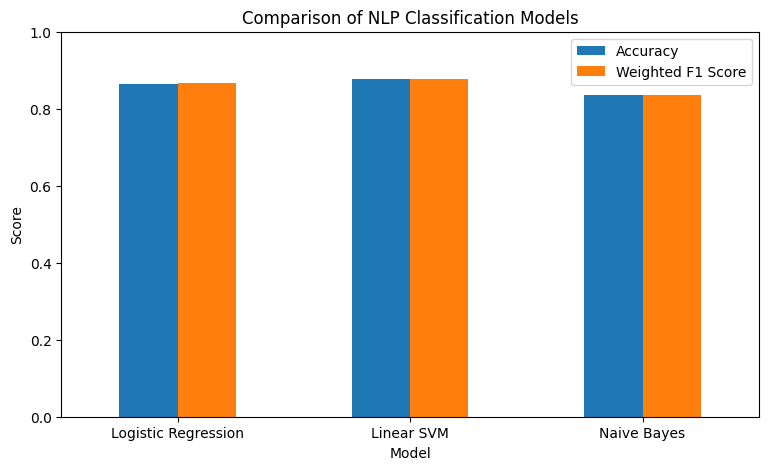

In [ ]:
results.set_index('Model')[
    ['Accuracy', 'Weighted F1 Score']
].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Comparison of NLP Classification Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1)


plt.savefig(
    'model_comparision.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Confusion Matrix

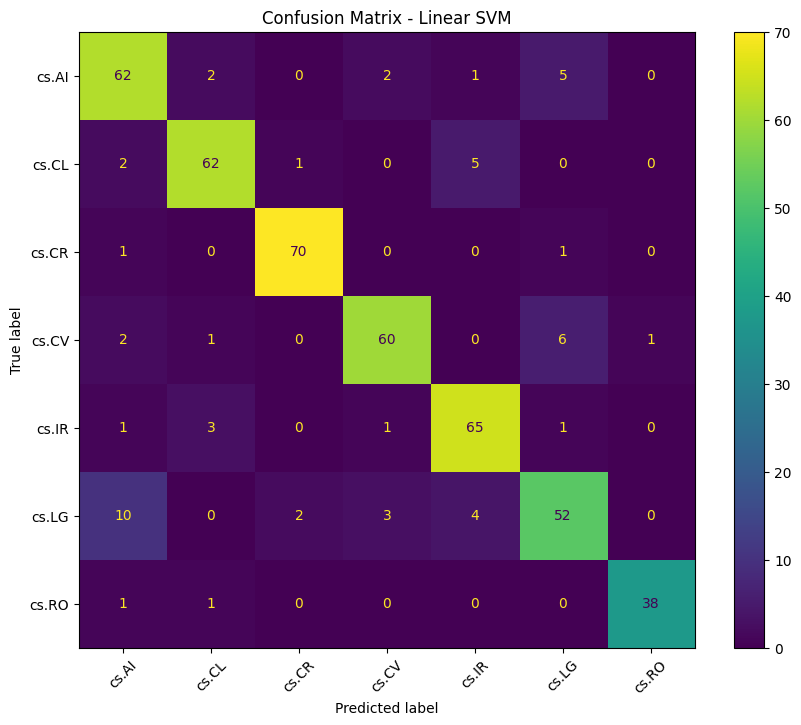

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=svm_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title('Confusion Matrix - Linear SVM')

plt.title('Confusion Matrix - Linear SVM')

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Hman readable topics name

In [ ]:
topic_names = {

    'cs.AI': 'Artificial Intelligence',

    'cs.LG': 'Machine Learning',

    'cs.CV': 'Computer Vision',

    'cs.CL': 'Natural Language Processing',

    'cs.CR': 'Cryptography and Security',

    'cs.IR': 'Information Retrieval',

    'cs.RO': 'Robotics'
}

## Predicting real paper

In [ ]:
def predict_topic(title, abstract):

    text = title + " " + abstract

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = svm_model.predict(vector)[0]

    return topic_names.get(
        prediction,
        prediction
    )

## Testing model

In [ ]:
title = "Deep Learning for Medical Image Classification"

abstract = """
This paper proposes a convolutional neural network
for automatic classification of medical images.
The proposed deep learning model learns visual
features directly from image datasets.
"""

prediction = predict_topic(
    title,
    abstract
)

print("Predicted Research Topic:")
print(prediction)

Predicted Research Topic:
Computer Vision


## 1 more...

In [ ]:
title = "Transformer Based Text Summarization"

abstract = """
We investigate transformer neural networks for
automatic text summarization and natural language
understanding.
"""

print(
    predict_topic(
        title,
        abstract
    )
)

Natural Language Processing


## Saving model

In [ ]:
import joblib

joblib.dump(
    svm_model,
    'research_topic_classifier.pkl'
)

joblib.dump(
    tfidf,
    'tfidf_vectorizer.pkl'
)

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
